<a href="https://colab.research.google.com/github/gabrielbecmar1932/Ingenieria-Logistica/blob/main/Short_path_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ingeniería Logística
# Shortest Path Problem


Resolvamos el problema de calcular el camino de costo mínimo del nodo $s=0$ al nodo $t=n-1$ en un grafo dirigido con costos positivos:

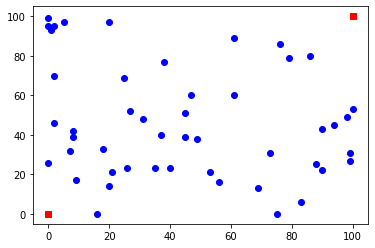

In [ ]:
n        = 20
nodes = range(n)
s = 0    # source
t = n-1  # target

import random
random.seed(5)
# Gerenamos aleatoriamente n puntos en el plano
points   = [(random.randint(0,100),random.randint(0,100)) for i in nodes]
# Para una mejor visialización ponemos en la esquina inferior izquierda s
# y t en la superior derecha
points[0]=[0,0]
points[n-1]=[100,100]

# Definemos una función para dibujar puntos y arcos
import matplotlib.pyplot as plt
def dibuja(selected):
    plt.plot([p[0] for p in points], [p[1] for p in points], 'bo')
    for (i,j) in selected:
        plt.plot([points[i][0],points[j][0]], [points[i][1],points[j][1]], 'g-')
    plt.plot(points[s][0],points[s][1], 'rs')
    plt.plot(points[t][0],points[t][1], 'rs')

dibuja({})




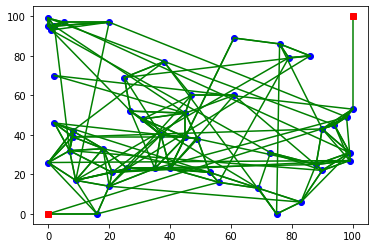

In [ ]:
import math
import numpy as np
cost =  np.zeros((n,n))
# Matriz de costos
# Igual a la distancia por una cantidad aleatoria (en [1.0 , 1.2])
# y una cantidad muy grande cuando está lejos
for i in nodes :
  for j in nodes:
    if j != i:
      dx = points[i][0] - points[j][0]
      dy = points[i][1] - points[j][1]
      dist = math.floor(math.sqrt(dx*dx + dy*dy)*random.uniform(1.0, 1.2))
      if dist > 20 and j != i + 1 :
        cost[i,j]= 1000
      else :
        cost[i,j] = dist

selected = [(i,j) for i in nodes for j in nodes if cost[i,j] < 200]
dibuja(selected)


In [ ]:
!pip install ortools
from ortools.linear_solver import pywraplp

Costo total =  176.0  in  0.263 seconds
Optimal path: [(0, 1), (1, 15), (15, 48), (48, 49)]


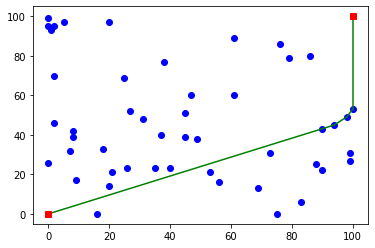

In [ ]:
solver = pywraplp.Solver('ShortestPath', pywraplp.Solver.CBC_MIXED_INTEGER_PROGRAMMING)

x = { (i,j) : solver.BoolVar('x[%i, %i]' % (i, j)) for i in nodes for j in nodes }
y = { i : solver.BoolVar('y[%i]' % i) for i in nodes }

solver.Minimize( solver.Sum(cost[i,j] * x[i,j] for i in nodes for j in nodes if i!=j ) )

solver.Add(solver.Sum(x[s,j] for j in nodes if j!=s ) == 1)
solver.Add(solver.Sum(x[i,s] for i in nodes if i!=s ) == 0)
solver.Add(solver.Sum(x[i,t] for i in nodes if i!=t ) == 1)
solver.Add(solver.Sum(x[t,j] for j in nodes if j!=t ) == 0)
[ solver.Add(solver.Sum(x[i,j] for j in nodes if j!=i) == y[i]) for i in nodes if i!=s and i!=t ]
[ solver.Add(solver.Sum(x[i,j] for i in nodes if j!=i) == y[j]) for j in nodes if j!=s and j!=t ]


solver.Solve()

print('Costo total = ', solver.Objective().Value()," in ", solver.WallTime()/1000, "seconds")
selected = [(i,j) for i in nodes for j in nodes if x[i,j].solution_value() > 0.5]
print('Optimal path: %s' % str(selected))
dibuja(selected)